# ⚙️ Notebook 2 — Preprocessing & Balancing
**Project:** Smartphone Addiction Prediction  
**Goal:** Clean the data, encode features, scale, handle class imbalance, and save processed splits ready for modeling.

---

## 1. Imports & Configuration

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from collections import Counter

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

DATA_PATH   = '../data/Smartphone_Usage_And_Addiction.csv'
OUTPUT_DIR  = Path('../outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42

## 2. Load Raw Data

In [14]:
df = pd.read_csv(DATA_PATH)
print(f'Raw shape: {df.shape}')
df.head()

Raw shape: (7500, 16)


,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


## 3. Drop Leakage & Identifier Columns

In [15]:
# addiction_level is an ordinal version of our binary target — drop to prevent leakage
DROP_COLS = ['transaction_id', 'user_id', 'addiction_level']
df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])
print(f'Shape after dropping leakage columns: {df.shape}')
print('Remaining columns:', df.columns.tolist())

Shape after dropping leakage columns: (7500, 13)
Remaining columns: ['age', 'gender', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'stress_level', 'academic_work_impact', 'addicted_label']


## 4. Handle Missing Values

In [16]:
print('Missing values before imputation:')
print(df.isnull().sum()[df.isnull().sum() > 0])

# Numerical columns — fill with median (robust to outliers)
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# Categorical columns — fill with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print(f'\nMissing values after imputation: {df.isnull().sum().sum()}')

Missing values before imputation:
Series([], dtype: int64)

Missing values after imputation: 0


## 5. Remove Duplicates

In [17]:
before = len(df)
df = df.drop_duplicates()
print(f'Removed {before - len(df)} duplicate rows. Shape: {df.shape}')

Removed 0 duplicate rows. Shape: (7500, 13)


## 6. Encode Categorical Features

In [18]:
# Ordinal encoding for meaningful order
ORDINAL_MAPS = {
    'stress_level': {'Low': 0, 'Medium': 1, 'High': 2},
    'academic_work_impact': {'No': 0, 'Yes': 1},
}

for col, mapping in ORDINAL_MAPS.items():
    if col in df.columns:
        df[col] = df[col].map(mapping)
        print(f'Ordinal encoded: {col}')

# Nominal encoding for gender (no inherent order)
if 'gender' in df.columns:
    gender_map = {v: i for i, v in enumerate(df['gender'].unique())}
    df['gender'] = df['gender'].map(gender_map)
    print(f'Label encoded: gender → {gender_map}')
    joblib.dump(gender_map, OUTPUT_DIR / 'gender_map.pkl')

# One-hot encode remaining nominal columns
remaining_cat = df.select_dtypes(include='object').columns.tolist()
if remaining_cat:
    df = pd.get_dummies(df, columns=remaining_cat, drop_first=True)
    print(f'One-hot encoded: {remaining_cat}')

print(f'\nShape after encoding: {df.shape}')
df.head()

Ordinal encoded: stress_level
Ordinal encoded: academic_work_impact
Label encoded: gender → {'Male': 0, 'Other': 1, 'Female': 2}

Shape after encoding: (7500, 13)


,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addicted_label
0,21,0,3.23,2.01,0.89,4.55,7.55,248,154,3.95,1,1,0
1,24,1,5.09,3.81,2.24,4.44,7.66,127,71,6.71,1,1,0
2,31,1,6.06,1.36,3.83,2.35,4.92,44,106,8.68,2,0,0
3,32,1,7.83,5.85,1.51,3.54,8.23,178,107,9.77,2,1,1
4,25,0,9.96,5.92,3.42,5.27,6.21,136,177,12.55,0,0,1


## 7. Outlier Capping (IQR Winsorization)

In [19]:
TARGET = 'addicted_label'
feature_cols = [c for c in df.columns if c != TARGET]

for col in feature_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)

print('Outlier capping (IQR Winsorization) applied to all features.')

Outlier capping (IQR Winsorization) applied to all features.


## 8. Train / Validation / Test Split

In [20]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

# 70% train | 15% val | 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp)

print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')
print(f'Train class dist: {Counter(y_train)}')

Train: (5250, 12)  Val: (1125, 12)  Test: (1125, 12)
Train class dist: Counter({1: 3716, 0: 1534})


## 9. Feature Scaling

In [21]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_val_scaled   = pd.DataFrame(
    scaler.transform(X_val),   columns=X_val.columns,   index=X_val.index)
X_test_scaled  = pd.DataFrame(
    scaler.transform(X_test),  columns=X_test.columns,  index=X_test.index)

joblib.dump(scaler, OUTPUT_DIR / 'scaler.pkl')
print('StandardScaler fitted and saved → outputs/scaler.pkl')

StandardScaler fitted and saved → outputs/scaler.pkl


## 10. Class Balancing Strategies

We compare three approaches and save **SMOTE** as default (best for tree-based + linear models).

In [22]:
print('Original class distribution:', Counter(y_train))

# --- A) SMOTE (Over-sampling) ---
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print('After SMOTE:            ', Counter(y_train_smote))

# --- B) Random Under-Sampling ---
rus = RandomUnderSampler(random_state=RANDOM_STATE)
X_train_under, y_train_under = rus.fit_resample(X_train_scaled, y_train)
print('After Under-Sampling:   ', Counter(y_train_under))

# --- C) Combined SMOTE + Tomek (already in imbalanced-learn) ---
from imblearn.combine import SMOTETomek
smt = SMOTETomek(random_state=RANDOM_STATE)
X_train_smt, y_train_smt = smt.fit_resample(X_train_scaled, y_train)
print('After SMOTE + Tomek:    ', Counter(y_train_smt))

Original class distribution: Counter({1: 3716, 0: 1534})
After SMOTE:             Counter({0: 3716, 1: 3716})
After Under-Sampling:    Counter({0: 1534, 1: 1534})
After SMOTE + Tomek:     Counter({0: 3681, 1: 3681})


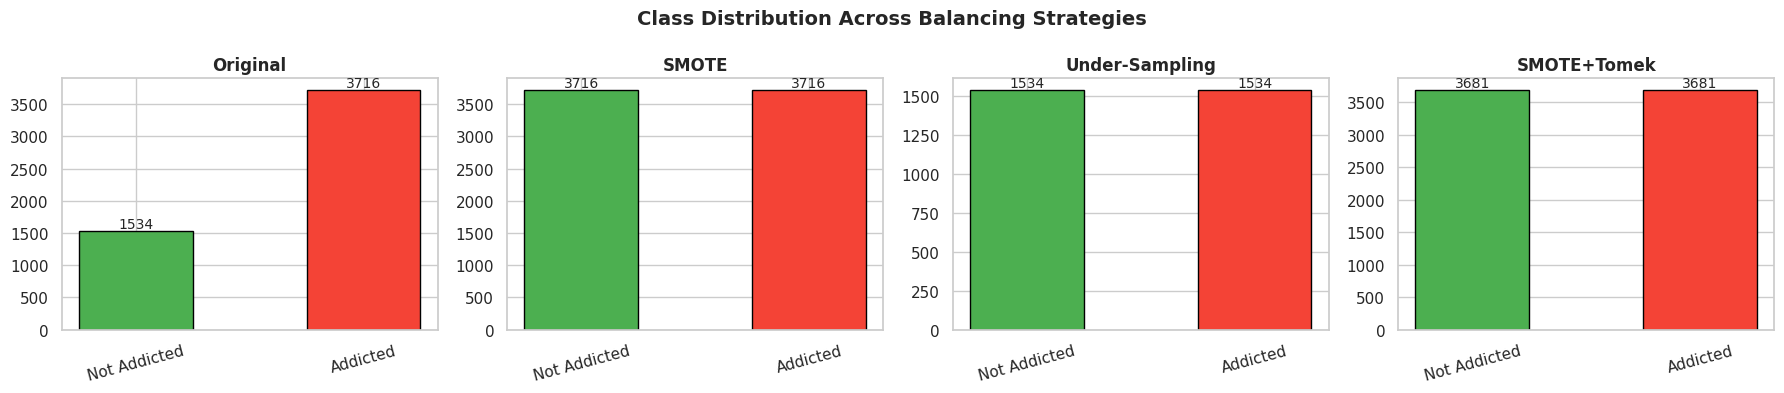

In [23]:
# Visualize class balance comparison
strategies = {
    'Original': Counter(y_train),
    'SMOTE': Counter(y_train_smote),
    'Under-Sampling': Counter(y_train_under),
    'SMOTE+Tomek': Counter(y_train_smt)
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
colors = [['#4CAF50', '#F44336']] * 4

for ax, (name, cnt), clr in zip(axes, strategies.items(), colors):
    bars = ax.bar([0, 1], [cnt[0], cnt[1]], color=clr, edgecolor='black', width=0.5)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Not Addicted', 'Addicted'], rotation=15)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)

plt.suptitle('Class Distribution Across Balancing Strategies', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '02_class_balancing.png', bbox_inches='tight')
plt.show()

## 11. Save Processed Data

In [24]:
# Save all splits for the modeling notebook
splits = {
    'X_train': X_train_smote,        # SMOTE-balanced training set
    'y_train': pd.Series(y_train_smote, name='addicted_label'),
    'X_val':   X_val_scaled,
    'y_val':   y_val,
    'X_test':  X_test_scaled,
    'y_test':  y_test,
    # Also save unbalanced scaled train for models that handle imbalance internally
    'X_train_raw_scaled': X_train_scaled,
    'y_train_raw':        y_train,
}

for name, data in splits.items():
    data.to_csv(OUTPUT_DIR / f'{name}.csv', index=False)
    print(f'Saved {name}.csv  shape={data.shape}')

# Save feature names list
joblib.dump(list(X_train.columns), OUTPUT_DIR / 'feature_names.pkl')
print('\n✅ All processed data saved to outputs/')

Saved X_train.csv  shape=(7432, 12)
Saved y_train.csv  shape=(7432,)
Saved X_val.csv  shape=(1125, 12)
Saved y_val.csv  shape=(1125,)
Saved X_test.csv  shape=(1125, 12)
Saved y_test.csv  shape=(1125,)
Saved X_train_raw_scaled.csv  shape=(5250, 12)
Saved y_train_raw.csv  shape=(5250,)

✅ All processed data saved to outputs/


## 12. Preprocessing Summary

| Step | Action |
|------|--------|
| Leakage removal | Dropped `transaction_id`, `user_id`, `addiction_level` |
| Missing values | Median (numerical) / Mode (categorical) |
| Duplicates | Removed |
| Encoding | Ordinal maps + label encoding + one-hot |
| Outliers | IQR Winsorization (clip) |
| Splitting | 70 / 15 / 15 (train / val / test), stratified |
| Scaling | StandardScaler (fit on train only) |
| Balancing | SMOTE on training set only |